In [1]:
import sys
from pathlib import Path
from fa_scripts.io import load_all, quick_healthcheck, save_checkpoint
frames = load_all()
quick_healthcheck(frames)
# Optionally write a checkpoint of exactly-what-we-loaded
save_checkpoint(frames, suffix="phase1_raw_snapshot")


[INFO] Loaded fbref_team_defense.csv: 2,744 rows × 30 cols
[INFO] Loaded fbref_team_goal_shot_creation.csv: 2,744 rows × 28 cols
[INFO] Loaded fbref_team_match_stats.csv: 2,744 rows × 189 cols
[INFO] Loaded fbref_team_misc.csv: 2,744 rows × 30 cols
[INFO] Loaded fbref_team_passing.csv: 2,744 rows × 36 cols
[INFO] Loaded fbref_team_possession.csv: 2,744 rows × 37 cols
[INFO] Loaded fbref_team_schedule.csv: 2,744 rows × 23 cols
[INFO] Loaded fbref_team_shooting.csv: 2,744 rows × 29 cols
[INFO] Loaded understat_team_matches.csv: 1,372 rows × 27 cols
[INFO] Checkpoint saved to E:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\data\processed\phase1_raw_snapshot


STEP 0 – Imports & Load

In [2]:
# CELL 0
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from fa_scripts.io import load_all, quick_healthcheck

# pandas display prefs
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

frames = load_all()        # dict[str, DataFrame]
list(frames.keys())





[INFO] Loaded fbref_team_defense.csv: 2,744 rows × 30 cols
[INFO] Loaded fbref_team_goal_shot_creation.csv: 2,744 rows × 28 cols
[INFO] Loaded fbref_team_match_stats.csv: 2,744 rows × 189 cols
[INFO] Loaded fbref_team_misc.csv: 2,744 rows × 30 cols
[INFO] Loaded fbref_team_passing.csv: 2,744 rows × 36 cols
[INFO] Loaded fbref_team_possession.csv: 2,744 rows × 37 cols
[INFO] Loaded fbref_team_schedule.csv: 2,744 rows × 23 cols
[INFO] Loaded fbref_team_shooting.csv: 2,744 rows × 29 cols
[INFO] Loaded understat_team_matches.csv: 1,372 rows × 27 cols


['fbref_team_defense',
 'fbref_team_goal_shot_creation',
 'fbref_team_match_stats',
 'fbref_team_misc',
 'fbref_team_passing',
 'fbref_team_possession',
 'fbref_team_schedule',
 'fbref_team_shooting',
 'understat_team_matches']

STEP 1: Initial Data Health Check

In [3]:
# CELL 1.1 — Healthcheck overview
hc = quick_healthcheck(frames)
hc


,name,rows,cols,non_null_pct,min_date,max_date
0,fbref_team_defense,2744,30,99.97,2020-08-21 00:00:00,2025-05-17 00:00:00
1,fbref_team_goal_shot_creation,2744,28,99.96,2020-08-21 00:00:00,2025-05-17 00:00:00
2,fbref_team_match_stats,2744,189,99.80,2020-08-21 00:00:00,2025-05-17 00:00:00
3,fbref_team_misc,2744,30,99.99,2020-08-21 00:00:00,2025-05-17 00:00:00
4,fbref_team_passing,2744,36,99.96,2020-08-21 00:00:00,2025-05-17 00:00:00
5,fbref_team_possession,2744,37,99.96,2020-08-21 00:00:00,2025-05-17 00:00:00
6,fbref_team_schedule,2744,23,98.79,2020-08-21 00:00:00,2025-05-17 00:00:00
7,fbref_team_shooting,2744,29,99.88,2020-08-21 00:00:00,2025-05-17 00:00:00
8,understat_team_matches,1372,27,100.00,2020-08-21 17:00:00,2025-05-17 19:00:00


In [4]:
# CELL 1.2 — Per-table: head(3), dtypes, missing summary
def df_missing_summary(df: pd.DataFrame):
    s = df.isna().mean().sort_values(ascending=False).rename("null_rate")
    return pd.DataFrame({"null_rate": (100*s).round(2)})

for name, df in frames.items():
    print(f"\n=== {name} ===")
    #display(df.head(3))
    #display(df.dtypes.to_frame("dtype"))
    #display(df_missing_summary(df))



=== fbref_team_defense ===

=== fbref_team_goal_shot_creation ===

=== fbref_team_match_stats ===

=== fbref_team_misc ===

=== fbref_team_passing ===

=== fbref_team_possession ===

=== fbref_team_schedule ===

=== fbref_team_shooting ===

=== understat_team_matches ===


STEP 2: Data Integration Analysis

2.1 Identify likely merge keys

In [5]:
# CELL 2.1 — candidate keys scan
KEY_CANDIDATES = ["team","squad","opponent","is_home","home","away",
                  "date","match_date","season","round","match_id"]

def scan_keys(frames):
    out = []
    for name, df in frames.items():
        cols = set(df.columns)
        present = [k for k in KEY_CANDIDATES if k in cols]
        out.append({"table": name, "keys_present": ", ".join(present)})
    return pd.DataFrame(out)

scan_keys(frames)


,table,keys_present
0,fbref_team_defense,"team, date, season, round"
1,fbref_team_goal_shot_creation,"team, date, season, round"
2,fbref_team_match_stats,"team, date, season, round"
3,fbref_team_misc,"team, date, season, round"
4,fbref_team_passing,"team, date, season, round"
5,fbref_team_possession,"team, date, season, round"
6,fbref_team_schedule,"team, date, season, round"
7,fbref_team_shooting,"team, date, season, round"
8,understat_team_matches,"date, match_date"


In [6]:
# CELL 2.2 — team name sets per table & overlaps
def get_team_col(df):
    for c in ["team","squad","home","away","home_team","away_team","Team"]:
        if c in df.columns:
            return c
    return None

team_sets = {}
for name, df in frames.items():
    c = get_team_col(df)
    if c is None: 
        continue
    # pull both home/away if they exist
    candidates = []
    if {"home","away"}.issubset(df.columns):
        candidates = pd.concat([df["home"], df["away"]], ignore_index=True).dropna().unique()
    else:
        candidates = df[c].dropna().unique()
    team_sets[name] = set(map(str, candidates))

# pairwise differences vs a reference table (choose schedule if present)
ref_name = "fbref_team_schedule" if "fbref_team_schedule" in frames else list(team_sets.keys())[0]
ref_set = team_sets.get(ref_name, set())

rows = []
for name, tset in team_sets.items():
    rows.append({
        "table": name,
        "n_teams": len(tset),
        "missing_vs_ref": sorted(list(ref_set - tset))[:5],
        "extra_vs_ref": sorted(list(tset - ref_set))[:5]
    })
pd.DataFrame(rows).sort_values("table")


,table,n_teams,missing_vs_ref,extra_vs_ref
0,fbref_team_defense,26,[],[]
1,fbref_team_goal_shot_creation,26,[],[]
2,fbref_team_match_stats,26,[],[]
3,fbref_team_misc,26,[],[]
4,fbref_team_passing,26,[],[]
5,fbref_team_possession,26,[],[]
6,fbref_team_schedule,26,[],[]
7,fbref_team_shooting,26,[],[]
8,understat_team_matches,26,"[Nîmes, Paris S-G, Saint-Étienne]","[Nimes, Paris Saint Germain, Saint-Etienne]"


Interpretation:

Any non-empty missing_vs_ref or extra_vs_ref means naming mismatches (e.g., “Paris S-G” vs “Paris Saint-Germain”). We’ll fix with an explicit name_map.py(no fuzzy/silent fallbacks).

2.3 Date coverage alignment

In [7]:
# CELL 2.3 — date/season coverage per table
DATE_COLS = ["date","match_date","Date"]
SEASON_COLS = ["season","Season","year","Year"]

def date_range(df):
    for c in DATE_COLS:
        if c in df.columns and pd.api.types.is_datetime64_any_dtype(df[c]):
            return df[c].min(), df[c].max()
    return None, None

def season_range(df):
    for c in SEASON_COLS:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            return s.min(), s.max()
    return None, None

rows = []
for name, df in frames.items():
    dmin, dmax = date_range(df)
    smin, smax = season_range(df)
    rows.append({"table": name, "date_min": dmin, "date_max": dmax, "season_min": smin, "season_max": smax})
pd.DataFrame(rows).sort_values("table")


,table,date_min,date_max,season_min,season_max
0,fbref_team_defense,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
1,fbref_team_goal_shot_creation,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
2,fbref_team_match_stats,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
3,fbref_team_misc,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
4,fbref_team_passing,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
5,fbref_team_possession,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
6,fbref_team_schedule,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
7,fbref_team_shooting,2020-08-21 00:00:00,2025-05-17 00:00:00,2021.0,2425.0
8,understat_team_matches,2020-08-21 17:00:00,2025-05-17 19:00:00,NaN,NaN


Interpretation:

Tables should roughly align in coverage. If xG/xA start later than other stats, we’ll add season-aware backfilling/priors in Phase 2.

STEP 3: Target Variable Exploration

We’ll standardize a match schedule then expand to team rows (team/opponent/is_home/goals/result).

In [8]:
import re

def _normalise(col: str) -> str:
    col = re.sub(r'(?<!^)(?=[A-Z])', '_', col)          # camelCase → snake_case
    col = re.sub(r'[^0-9a-zA-Z]+', '_', col)            # spaces/punctuation → _
    return col.strip('_').lower()

def standardize_schedule(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={c: _normalise(c) for c in df.columns})

    aliases = {
        "date":   ["date", "match_date", "datetime", "kickoff", "game_date"],
        "home":   ["home", "venue", "home_team", "hometeam", "home_club", "home_team_name"],
        "away":   ["away", "venue", "away_team", "awayteam", "away_club", "away_team_name"],
        "hg":     ["home_goals", "homegoal", "home_score", "score_home", "fthg"],
        "ag":     ["away_goals", "awaygoal", "away_score", "score_away", "ftha"],
        "season": ["season", "season_id", "year", "season_year"],
    }

    def pick(kind: str) -> str | None:
        for cand in aliases[kind]:
            if cand in df.columns:
                return cand
        return None

    date_c = pick("date")
    home_c = pick("home")
    away_c = pick("away")
    hg_c   = pick("hg")
    ag_c   = pick("ag")
    season_c = pick("season")

    missing = {k: aliases[k] for k, col in
               [("date", date_c), ("home", home_c), ("away", away_c), ("hg", hg_c), ("ag", ag_c)]
               if col is None}
    if missing:
        raise ValueError(
            "Schedule columns not detected "
            f"(checked aliases: {missing}). Available columns: {sorted(df.columns)}"
        )

    out = df[[date_c, home_c, away_c, hg_c, ag_c] + ([season_c] if season_c else [])].copy()
    out.columns = ["date", "home", "away", "home_goals", "away_goals"] + (["season"] if season_c else [])
    if not pd.api.types.is_datetime64_any_dtype(out["date"]):
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
    return out

schedule = None
if "fbref_team_schedule" in frames:
    try:
        schedule = standardize_schedule(frames["fbref_team_schedule"].copy())
    except ValueError as err:
        print(f"FBref schedule not usable: {err}")

if schedule is None:
    schedule = standardize_schedule(frames["understat_team_matches"].copy())

schedule.head()


FBref schedule not usable: Schedule columns not detected (checked aliases: {'hg': ['home_goals', 'homegoal', 'home_score', 'score_home', 'fthg'], 'ag': ['away_goals', 'awaygoal', 'away_score', 'score_away', 'ftha']}). Available columns: ['attendance', 'captain', 'date', 'day', 'formation', 'g_a', 'g_f', 'game', 'league', 'match_report', 'notes', 'opp', 'opp_formation', 'poss', 'referee', 'result', 'round', 'season', 'team', 'time', 'venue', 'x_g', 'x_g_a']


,date,home,away,home_goals,away_goals,season
0,2020-08-21 17:00:00,Bordeaux,Nantes,0,0,2020
1,2020-08-22 15:00:00,Dijon,Angers,0,1,2020
2,2020-08-22 19:00:00,Lille,Rennes,1,1,2020
3,2020-08-23 13:00:00,Lorient,Strasbourg,3,1,2020
4,2020-08-23 11:00:00,Monaco,Reims,2,2,2020


In [9]:
# CELL 3.2 - expand to team rows and label

def explode_to_team_rows(sched, understat=None):
    base = sched.copy()

    home = base.assign(
        team=base["home"],
        opponent=base["away"],
        is_home=1,
        gf=base["home_goals"],
        ga=base["away_goals"],
    )
    away = base.assign(
        team=base["away"],
        opponent=base["home"],
        is_home=0,
        gf=base["away_goals"],
        ga=base["home_goals"],
    )
    long = pd.concat([home, away], ignore_index=True)
    long["result"] = np.where(
        long["gf"] > long["ga"],
        "win",
        np.where(long["gf"] < long["ga"], "loss", "draw"),
    )
    long["match_id"] = (
        long["date"].dt.strftime("%Y%m%d")
        + "_"
        + long["home"]
        + "_"
        + long["away"]
    )

    if understat is not None and not understat.empty:
        ust = understat.copy()
        ust.columns = [c.lower() for c in ust.columns]

        date_col = next((c for c in ["date", "match_date", "datetime"] if c in ust.columns), None)
        home_team_col = next((c for c in ["home_team", "hometeam", "home"] if c in ust.columns), None)
        away_team_col = next((c for c in ["away_team", "awayteam", "away"] if c in ust.columns), None)

        if date_col and home_team_col and away_team_col:
            ust[date_col] = pd.to_datetime(ust[date_col], errors="coerce")

            metric_pairs = {
                "xg": ("home_xg", "away_xg"),
                "np_xg": ("home_np_xg", "away_np_xg"),
                "expected_points": ("home_expected_points", "away_expected_points"),
                "ppda": ("home_ppda", "away_ppda"),
                "deep_completions": ("home_deep_completions", "away_deep_completions"),
            }

            parts = []
            for side, team_col, is_home in [
                ("home", home_team_col, 1),
                ("away", away_team_col, 0),
            ]:
                cols = [date_col, team_col]
                rename_map = {date_col: "date", team_col: "team"}
                for feat, pair in metric_pairs.items():
                    col_name = pair[0] if side == "home" else pair[1]
                    if col_name in ust.columns:
                        cols.append(col_name)
                        rename_map[col_name] = feat
                part = ust[cols].rename(columns=rename_map)
                part["is_home"] = is_home
                parts.append(part)

            ust_long = pd.concat(parts, ignore_index=True)
            long = long.merge(ust_long, on=["team", "date", "is_home"], how="left")
        else:
            print("Understat merge skipped: date/team columns not detected.")

    return long

team_rows = explode_to_team_rows(
    schedule,
    understat=frames.get("understat_team_matches"),
)
team_rows.head()


,date,home,away,home_goals,away_goals,season,team,opponent,is_home,gf,ga,result,match_id,xg,np_xg,expected_points,ppda,deep_completions
0,2020-08-21 17:00:00,Bordeaux,Nantes,0,0,2020,Bordeaux,Nantes,1,0,0,draw,20200821_Bordeaux_Nantes,0.600075,0.600075,1.8613,24.461538,0
1,2020-08-22 15:00:00,Dijon,Angers,0,1,2020,Dijon,Angers,1,0,1,loss,20200822_Dijon_Angers,0.739709,0.739709,0.4217,22.000000,5
2,2020-08-22 19:00:00,Lille,Rennes,1,1,2020,Lille,Rennes,1,1,1,draw,20200822_Lille_Rennes,0.400974,0.400974,0.5357,16.500000,1
3,2020-08-23 13:00:00,Lorient,Strasbourg,3,1,2020,Lorient,Strasbourg,1,3,1,win,20200823_Lorient_Strasbourg,3.072140,2.312110,2.9185,7.171429,2
4,2020-08-23 11:00:00,Monaco,Reims,2,2,2020,Monaco,Reims,1,2,2,draw,20200823_Monaco_Reims,2.676220,2.676220,1.9379,3.787879,14


In [10]:
# CELL 3.3 — distribution overall, home vs away, by season
dist_overall = team_rows["result"].value_counts(normalize=True).mul(100).round(1).rename("%")
dist_home = team_rows.groupby("is_home")["result"].value_counts(normalize=True).mul(100).round(1).unstack().rename_axis(index={0:"Away",1:"Home"})
dist_season = team_rows.groupby("season")["result"].value_counts(normalize=True).mul(100).round(1).unstack()

display(dist_overall.to_frame())
display(dist_home)
display(dist_season.fillna(0))


,%
result,
loss,38.0
win,38.0
draw,24.1


result,draw,loss,win
is_home,,,
0,24.1,41.4,34.5
1,24.1,34.5,41.4


result,draw,loss,win
season,,,
2020,25.0,37.5,37.5
2022,24.2,37.9,37.9
2023,26.5,36.8,36.8
2024,20.3,39.9,39.9


Expect home advantage (home win ~40–50%, draws ~23–30%). If draw share is extremely low, check parsing/label logic.

STEP 4: Feature Analysis for Key Metrics

In [11]:
# CELL 4.0 — where features live
FEATURE_HINTS = {
    "xg": ["xg","xg_for","xg_team","expg"],
    "xa": ["xa","x_a","exp_assist"],
    "possession": ["poss","possession","poss%","possession%"],
    "pass_accuracy": ["cmp%","pass%","completion%","pass_accuracy"],
    "clearances": ["clr","clearances"],
    "yellow_cards": ["crdy","yellow"],
    "red_cards": ["crdr","red"],
    "touches": ["touches","tchs"]
}

def find_columns(df, hints):
    cols = df.columns.str.lower()
    found = {}
    for k, needles in hints.items():
        hits = [df.columns[i] for i,c in enumerate(cols) if any(n in c for n in needles)]
        if hits:
            found[k] = hits
    return found

feature_map = {name: find_columns(df.copy(), FEATURE_HINTS) for name, df in frames.items()}
pd.DataFrame(
    [{"table":k, **{m: ", ".join(v.get(m, [])) for m in FEATURE_HINTS}} for k,v in feature_map.items()]
).sort_values("table")


,table,xg,xa,possession,pass_accuracy,clearances,yellow_cards,red_cards,touches
0,fbref_team_defense,,,,,Clr,,,
1,fbref_team_goal_shot_creation,,,,,,,,
2,fbref_team_match_stats,"xG, xGA, Expected_xG, Expected_npxG, Expected_...","xAG, xA","Poss, Poss_dup","Total_Cmp%, Short_Cmp%, Medium_Cmp%, Long_Cmp%",Clr,"Performance_CrdY, Performance_2CrdY",Performance_CrdR,"Touches_Touches, Touches_Def Pen, Touches_Def ..."
3,fbref_team_misc,,,,,,"Performance_CrdY, Performance_2CrdY",Performance_CrdR,
4,fbref_team_passing,,"xAG, xA",,"Total_Cmp%, Short_Cmp%, Medium_Cmp%, Long_Cmp%",,,,
5,fbref_team_possession,,,Poss,,,,,"Touches_Touches, Touches_Def Pen, Touches_Def ..."
6,fbref_team_schedule,"xG, xGA",,Poss,,,,,
7,fbref_team_shooting,"Expected_xG, Expected_npxG, Expected_npxG/Sh, ...",,,,,,,
8,understat_team_matches,"home_xg, home_np_xg, home_np_xg_difference, aw...",,,,,,,


Use this table to confirm where to pull each feature from (typical: xG/xA from Understat, possession/pass accuracy from FBref passing/possession, cards from FBref misc/defense).

4.1 xG / xA distributions & by outcome

In [12]:
# CELL 4.1 — xG/xA from Understat (team rows)
ust = frames.get("understat_team_matches", pd.DataFrame()).copy()
cols = ust.columns.str.lower()

# Try to standardize per-team xG/xA per match
xg_col = next((c for c in ust.columns if c.lower() in ["xg","xg_for","team_xg"]), None)
xa_col = next((c for c in ust.columns if c.lower() in ["xa","x_a","team_xa"]), None)
team_col = next((c for c in ust.columns if c.lower() in ["team","squad","h_team","a_team"]), None)
date_col = next((c for c in ust.columns if c.lower() in ["date","match_date"]), None)

if {"xg", "np_xg", "expected_points"}.issubset(team_rows.columns):
    xr = team_rows[["team", "date", "result", "xg", "np_xg", "expected_points"]].copy()

    display(xr["xg"].describe(percentiles=[.1, .25, .5, .75, .9]))
    display(xr.groupby("result")["xg"].mean().rename("xg_mean_by_result"))

    if "np_xg" in xr:
        display(xr.groupby("result")["np_xg"].mean().rename("np_xg_mean_by_result"))
    if "expected_points" in xr:
        display(xr.groupby("result")["expected_points"].mean().rename("xpts_mean_by_result"))
else:
    print("Understat-derived columns not present in team_rows—re-run Cell 3.2.")


count    2744.000000
mean        1.474015
std         0.910553
min         0.000000
10%         0.454261
25%         0.786474
50%         1.327160
75%         1.961907
90%         2.713881
max         5.942360
Name: xg, dtype: float64

result
draw    1.301848
loss    1.041969
win     2.015111
Name: xg_mean_by_result, dtype: float64

result
draw    1.178601
loss    0.955008
win     1.797301
Name: np_xg_mean_by_result, dtype: float64

result
draw    1.368491
loss    0.794760
win     1.996800
Name: xpts_mean_by_result, dtype: float64

In [13]:
# CELL 4.2 - possession/pass accuracy (FBref tables with normalized dates)
poss_df = frames.get("fbref_team_possession", pd.DataFrame()).copy()
pass_df = frames.get("fbref_team_passing", pd.DataFrame()).copy()


def pick_col(df, needles):
    for c in df.columns:
        cl = c.lower()
        if any(n in cl for n in needles):
            return c
    return None


metrics = team_rows.copy()
metrics["match_day"] = metrics["date"].dt.normalize()

# --- possession ---
if not poss_df.empty:
    team_c = pick_col(poss_df, ["team", "squad"])
    date_c = pick_col(poss_df, ["date", "match_date"])
    poss_c = pick_col(poss_df, ["poss", "possession"])

    if all([team_c, date_c, poss_c]):
        tpos = poss_df[[team_c, date_c, poss_c]].copy()
        tpos.columns = ["team", "date_raw", "poss"]
        tpos["date_raw"] = pd.to_datetime(tpos["date_raw"], errors="coerce")
        tpos["match_day"] = tpos["date_raw"].dt.normalize()
        tpos["poss"] = pd.to_numeric(tpos["poss"], errors="coerce")
        metrics = metrics.merge(
            tpos[["team", "match_day", "poss"]],
            on=["team", "match_day"],
            how="left",
        )
    else:
        print("FBref possession columns not detected; inspect fbref_team_possession.")
else:
    print("FBref possession table missing or empty.")

# --- pass accuracy ---
if not pass_df.empty:
    team_c = pick_col(pass_df, ["team", "squad"])
    date_c = pick_col(pass_df, ["date", "match_date"])
    passacc_c = pick_col(pass_df, ["cmp%", "pass%", "completion%", "pass_accuracy"])

    if all([team_c, date_c, passacc_c]):
        tpass = pass_df[[team_c, date_c, passacc_c]].copy()
        tpass.columns = ["team", "date_raw", "pass_acc"]
        tpass["date_raw"] = pd.to_datetime(tpass["date_raw"], errors="coerce")
        tpass["match_day"] = tpass["date_raw"].dt.normalize()
        tpass["pass_acc"] = pd.to_numeric(tpass["pass_acc"], errors="coerce")
        metrics = metrics.merge(
            tpass[["team", "match_day", "pass_acc"]],
            on=["team", "match_day"],
            how="left",
        )
    else:
        print("FBref passing columns not detected; inspect fbref_team_passing.")
else:
    print("FBref passing table missing or empty.")

metrics = metrics.drop(columns=["match_day"])

# persist back into team_rows for downstream use
team_rows = metrics

available_cols = [c for c in ["poss", "pass_acc"] if c in team_rows.columns]
if available_cols:
    display(team_rows[available_cols].describe())
    display(team_rows.groupby("result")[available_cols].mean().round(2))
else:
    print("No possession or passing accuracy columns detected after merge.")



,poss,pass_acc
count,2484.000000,2483.000000
mean,49.328905,79.436971
std,10.754431,5.464347
min,16.000000,52.300000
25%,42.000000,76.200000
50%,49.000000,80.200000
75%,57.000000,83.400000
max,80.000000,92.500000


,poss,pass_acc
result,,
draw,49.25,78.79
loss,48.77,79.43
win,49.97,79.88


In [14]:
# CELL 4.3 - defensive/discipline (FBref tables with normalized dates)
misc_df = frames.get("fbref_team_misc", pd.DataFrame()).copy()
def_df = frames.get("fbref_team_defense", pd.DataFrame()).copy()


def pick_col(df, hints):
    for c in df.columns:
        if any(h in c.lower() for h in hints):
            return c
    return None


def extract_metrics(df, feature_specs):
    """Return normalized team/date subset with the requested features."""
    if df.empty:
        return pd.DataFrame()

    team_c = pick_col(df, ["team", "squad"])
    date_c = pick_col(df, ["date", "match_date"])
    if not team_c or not date_c:
        return pd.DataFrame()

    cols = [team_c, date_c]
    rename_map = {team_c: "team", date_c: "date_raw"}
    feature_names = []
    for out_name, hints in feature_specs:
        col = pick_col(df, hints)
        if col:
            cols.append(col)
            rename_map[col] = out_name
            feature_names.append(out_name)

    if len(cols) <= 2:  # nothing found
        return pd.DataFrame()

    out = df[cols].rename(columns=rename_map)
    out["date_raw"] = pd.to_datetime(out["date_raw"], errors="coerce")
    out["match_day"] = out["date_raw"].dt.normalize()
    for name in feature_names:
        out[name] = pd.to_numeric(out[name], errors="coerce")
    keep_cols = ["team", "match_day"] + feature_names
    return out[keep_cols]


metrics = team_rows.copy()
metrics["match_day"] = metrics["date"].dt.normalize()

clearances = extract_metrics(def_df, [("clearances", ["clr", "clear"])])
cards = extract_metrics(
    misc_df,
    [("yellow_cards", ["crdy", "yellow"]), ("red_cards", ["crdr", "red"])]
)

for extra in [clearances, cards]:
    if not extra.empty:
        metrics = metrics.merge(extra, on=["team", "match_day"], how="left")

metrics = metrics.drop(columns=["match_day"])

# persist features
team_rows = metrics

summary_cols = [c for c in ["clearances", "yellow_cards", "red_cards"] if c in team_rows.columns]
if summary_cols:
    display(team_rows[summary_cols].describe())
    display(team_rows.groupby("result")[summary_cols].mean(numeric_only=True).round(2))
else:
    print("No defensive/discipline features detected from FBref tables.")



,clearances,yellow_cards,red_cards
count,2483.000000,2484.000000,2484.000000
mean,19.082964,1.883655,0.126006
std,8.999080,1.288972,0.364317
min,1.000000,0.000000,0.000000
25%,13.000000,1.000000,0.000000
50%,18.000000,2.000000,0.000000
75%,24.000000,3.000000,0.000000
max,79.000000,8.000000,3.000000


,clearances,yellow_cards,red_cards
result,,,
draw,20.14,1.96,0.12
loss,16.81,1.90,0.16
win,20.78,1.82,0.09


Interpretation:

Winning sides tend to have higher xG, moderately higher possession/pass accuracy, and not necessarily fewer clearances (game state matters). Cards may correlate with losses; keep as features but beware causality direction.

STEP 5: Missing Data Assessment

In [15]:
# CELL 5.1 - missing by team/season for key metrics (using enriched team_rows)
KEY_COLS = {
    "xg": ["xg", "expected_xg", "team_xg"],
    "xa": ["xa", "expected_assists", "team_xa"],
    "poss": ["poss", "possession"],
    "pass_acc": ["pass_acc", "cmp%", "pass%"],
}

base = team_rows[["team", "date", "season"]].drop_duplicates()

metrics_found = {}
for alias, candidates in KEY_COLS.items():
    found = next((c for c in candidates if c in team_rows.columns), None)
    if found:
        sub = team_rows[["team", "date", found]].rename(columns={found: alias})
        base = base.merge(sub, on=["team", "date"], how="left")
        metrics_found[alias] = found

# ensure all keys exist so the summary table always has the same columns
for alias in KEY_COLS:
    if alias not in base.columns:
        base[alias] = pd.NA

metrics_columns = list(KEY_COLS.keys())

if base.empty:
    print("team_rows is empty - rerun earlier cells before computing missingness.")
else:
    null_by_season = (
        base.groupby("season")[metrics_columns]
            .apply(lambda df: df.isna().mean() * 100)
            .round(1)
    )
    display(null_by_season)



,xg,xa,poss,pass_acc
season,,,,
2020,0.0,100.0,15.0,15.0
2022,0.0,100.0,5.3,5.3
2023,0.0,100.0,6.2,6.2
2024,0.0,100.0,11.1,11.3


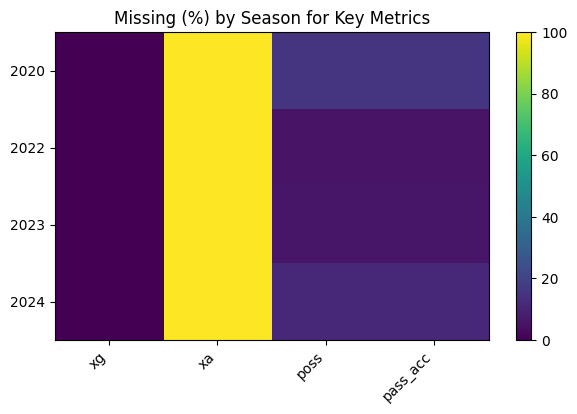

In [16]:
# CELL 5.2 — simple missing "heatmap" using matplotlib
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(null_by_season.values, aspect="auto")
ax.set_xticks(range(null_by_season.shape[1])); ax.set_xticklabels(null_by_season.columns, rotation=45, ha="right")
ax.set_yticks(range(null_by_season.shape[0])); ax.set_yticklabels(null_by_season.index)
ax.set_title("Missing (%) by Season for Key Metrics")
fig.colorbar(im, ax=ax)
plt.show()


If xA blanks in early seasons → plan a proxy (FBref shot-creating actions → GCA/SCA-based proxy) or drop from early windows.

If poss/pass_acc missing for a team in a season → check team name joins.

STEP 6: Correlations & Relationships

In [17]:
# CELL 6.1 — correlations per table (numeric only)
def corr_table(df, top=15):
    num = df.select_dtypes(include="number")
    if num.shape[1] < 2:
        return None
    c = num.corr(numeric_only=True)
    return c

for name, df in frames.items():
    c = corr_table(df)
    if c is None: 
        print(f"{name}: no numeric columns to correlate."); 
        continue
    print(f"\n{name} — correlation matrix (head)")
    display(c.iloc[:8, :8])



fbref_team_defense — correlation matrix (head)


,season,GF,GA,Tackles_Tkl,Tackles_TklW,Tackles_Def 3rd,Tackles_Mid 3rd,Tackles_Att 3rd
season,1.000000,0.021336,0.021336,0.083439,0.113276,0.042803,0.018787,0.119241
GF,0.021336,1.000000,-0.104136,0.009975,0.044773,-0.030853,0.038341,0.029188
GA,0.021336,-0.104136,1.000000,-0.058800,-0.062372,-0.009111,-0.062722,-0.043948
Tackles_Tkl,0.083439,0.009975,-0.058800,1.000000,0.820116,0.697428,0.627851,0.340596
Tackles_TklW,0.113276,0.044773,-0.062372,0.820116,1.000000,0.571279,0.522252,0.268174
Tackles_Def 3rd,0.042803,-0.030853,-0.009111,0.697428,0.571279,1.000000,-0.005281,-0.099986
Tackles_Mid 3rd,0.018787,0.038341,-0.062722,0.627851,0.522252,-0.005281,1.000000,0.120453
Tackles_Att 3rd,0.119241,0.029188,-0.043948,0.340596,0.268174,-0.099986,0.120453,1.000000



fbref_team_goal_shot_creation — correlation matrix (head)


,season,GF,GA,SCA Types_SCA,SCA Types_PassLive,SCA Types_PassDead,SCA Types_TO,SCA Types_Sh
season,1.000000,0.021336,0.021336,0.081673,0.108767,-0.019784,-0.020733,0.070866
GF,0.021336,1.000000,-0.104136,0.282402,0.267898,0.041701,0.172263,0.148106
GA,0.021336,-0.104136,1.000000,-0.113004,-0.112530,-0.015558,-0.073200,-0.053154
SCA Types_SCA,0.081673,0.282402,-0.113004,1.000000,0.938241,0.459318,0.365719,0.566439
SCA Types_PassLive,0.108767,0.267898,-0.112530,0.938241,1.000000,0.236318,0.229830,0.402848
SCA Types_PassDead,-0.019784,0.041701,-0.015558,0.459318,0.236318,1.000000,0.063877,0.347326
SCA Types_TO,-0.020733,0.172263,-0.073200,0.365719,0.229830,0.063877,1.000000,0.129430
SCA Types_Sh,0.070866,0.148106,-0.053154,0.566439,0.402848,0.347326,0.129430,1.000000



fbref_team_match_stats — correlation matrix (head)


...

,season,GF,GA,xG,xGA,Poss,Attendance
season,1.000000,0.021336,0.021336,0.056965,0.056965,0.000014,0.141939
GF,0.021336,1.000000,-0.104136,0.599985,-0.149026,0.119243,0.078226
GA,0.021336,-0.104136,1.000000,-0.149026,0.599985,-0.119308,0.078226
xG,0.056965,0.599985,-0.149026,1.000000,-0.240780,0.307086,0.080499
xGA,0.056965,-0.149026,0.599985,-0.240780,1.000000,-0.307183,0.080499
Poss,0.000014,0.119243,-0.119308,0.307086,-0.307183,1.000000,-0.000069
Attendance,0.141939,0.078226,0.078226,0.080499,0.080499,-0.000069,1.000000



fbref_team_shooting — correlation matrix (head)


,season,GF,GA,Standard_Gls,Standard_Sh,Standard_SoT,Standard_SoT%,Standard_G/Sh
season,1.000000,0.021336,0.021336,0.019786,0.072340,0.089489,0.040621,-0.009028
GF,0.021336,1.000000,-0.104136,0.986789,0.266248,0.539842,0.437961,0.735495
GA,0.021336,-0.104136,1.000000,-0.101339,-0.117574,-0.108949,-0.054361,-0.062094
Standard_Gls,0.019786,0.986789,-0.101339,1.000000,0.267391,0.541878,0.441428,0.747720
Standard_Sh,0.072340,0.266248,-0.117574,0.267391,1.000000,0.680954,-0.043096,-0.154369
Standard_SoT,0.089489,0.539842,-0.108949,0.541878,0.680954,1.000000,0.630300,0.235087
Standard_SoT%,0.040621,0.437961,-0.054361,0.441428,-0.043096,0.630300,1.000000,0.555767
Standard_G/Sh,-0.009028,0.735495,-0.062094,0.747720,-0.154369,0.235087,0.555767,1.000000



understat_team_matches — correlation matrix (head)


,league_id,season_id,game_id,home_team_id,away_team_id,home_points,home_expected_points,home_goals
league_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season_id,NaN,1.000000,0.975733,0.090596,0.090596,0.054109,0.055696,0.050831
game_id,NaN,0.975733,1.000000,0.072800,0.071684,0.048989,0.049477,0.052097
home_team_id,NaN,0.090596,0.072800,1.000000,-0.040028,-0.092562,-0.154078,-0.138176
away_team_id,NaN,0.090596,0.071684,-0.040028,1.000000,0.107806,0.169338,0.092633
home_points,NaN,0.054109,0.048989,-0.092562,0.107806,1.000000,0.606689,0.673402
home_expected_points,NaN,0.055696,0.049477,-0.154078,0.169338,0.606689,1.000000,0.510435
home_goals,NaN,0.050831,0.052097,-0.138176,0.092633,0.673402,0.510435,1.000000


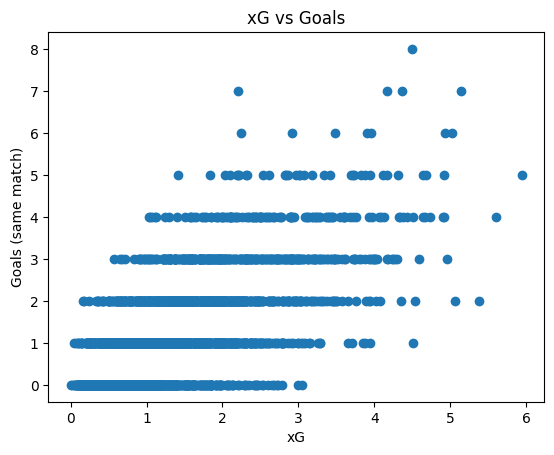

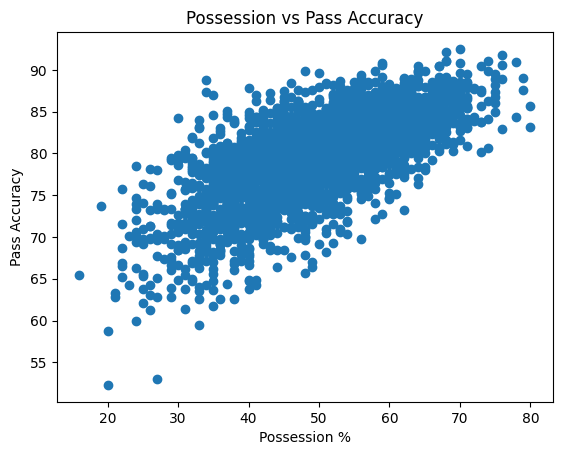

In [18]:
# CELL 6.2 — scatter: xG vs goals, possession vs pass accuracy
# (re-use 'metrics' from 4.2 and xr from 4.1)
fig, ax = plt.subplots()
if 'xg' in xr:
    ax.scatter(xr["xg"], team_rows.set_index(["team","date"]).loc[xr.set_index(["team","date"]).index, "gf"])
    ax.set_xlabel("xG"); ax.set_ylabel("Goals (same match)"); ax.set_title("xG vs Goals")
    plt.show()

fig, ax = plt.subplots()
if {"poss","pass_acc"}.issubset(metrics.columns):
    ax.scatter(metrics["poss"], metrics["pass_acc"])
    ax.set_xlabel("Possession %"); ax.set_ylabel("Pass Accuracy"); ax.set_title("Possession vs Pass Accuracy")
    plt.show()


Interpretation:

xG should correlate positively with goals (noisy but clear).

Possession and pass accuracy are related (moderate positive). Extremely weak relationships → check unit scaling or joins.

STEP 7: Time-Series & Rolling Trends

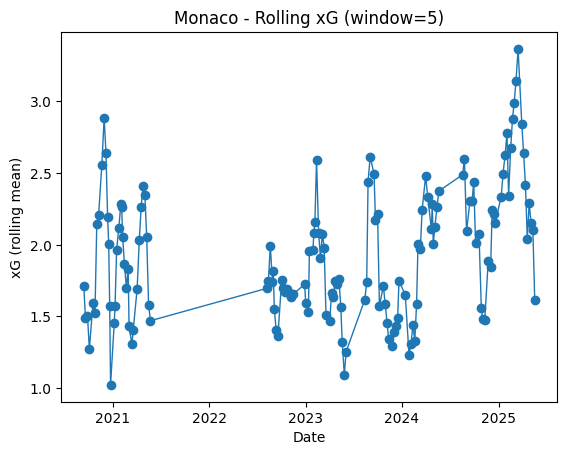

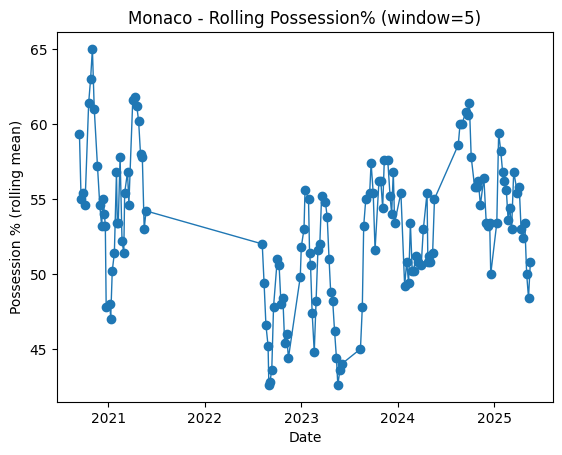

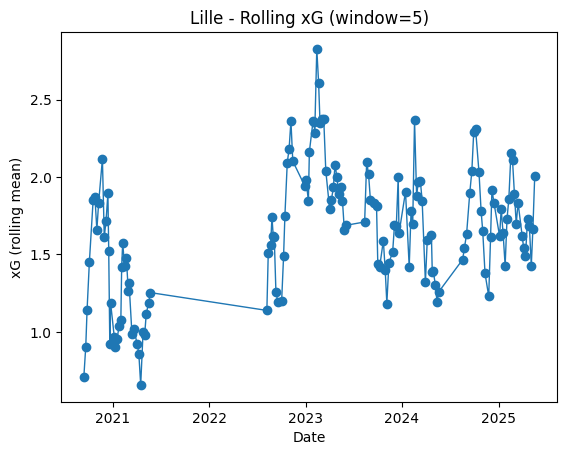

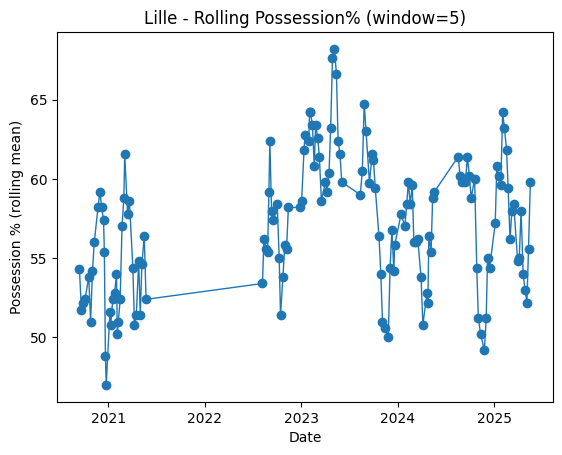

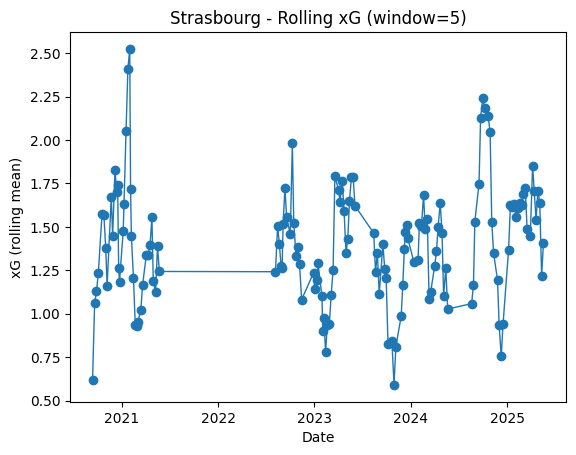

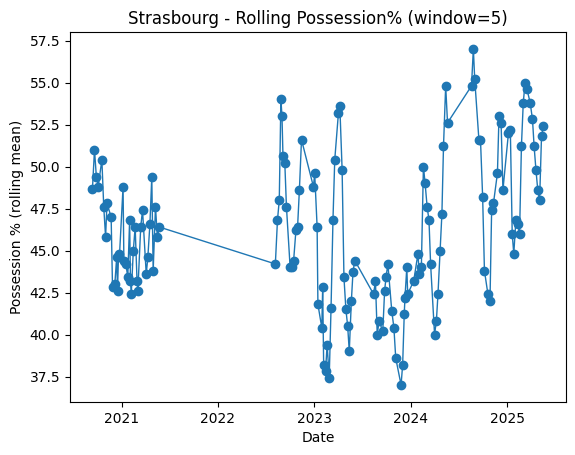

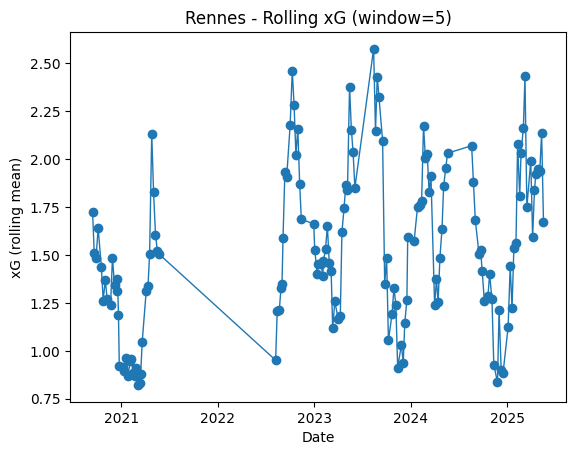

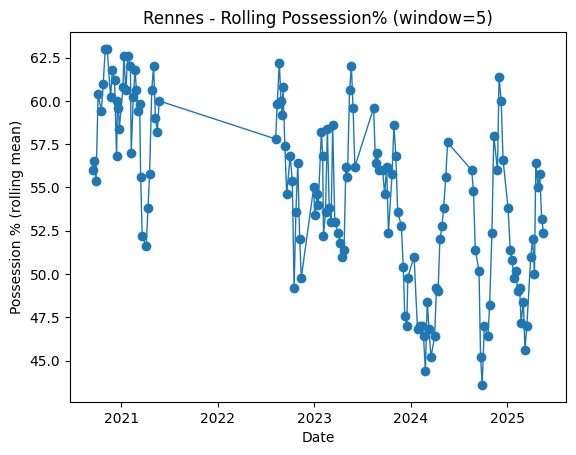

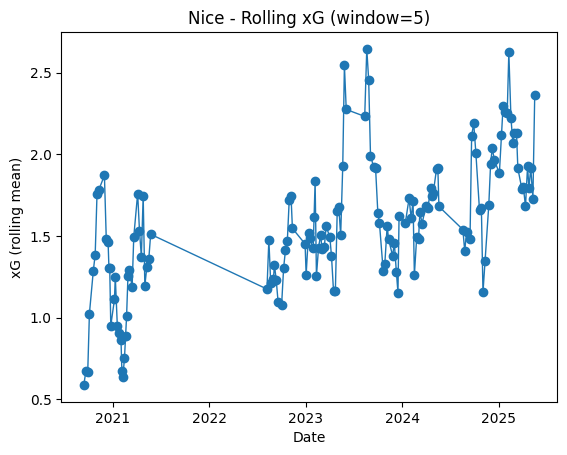

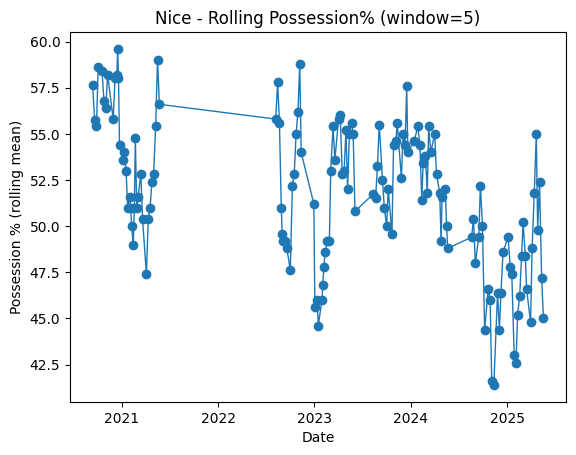

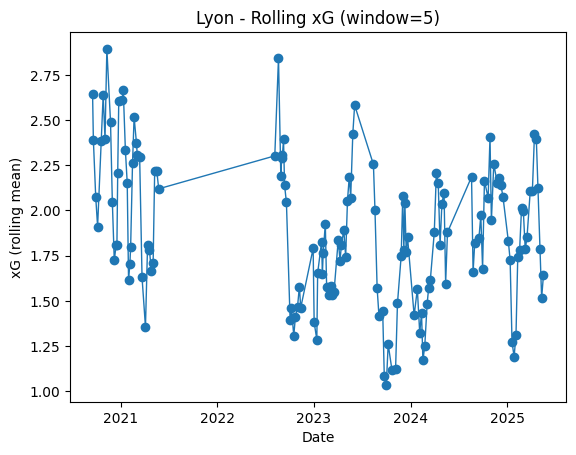

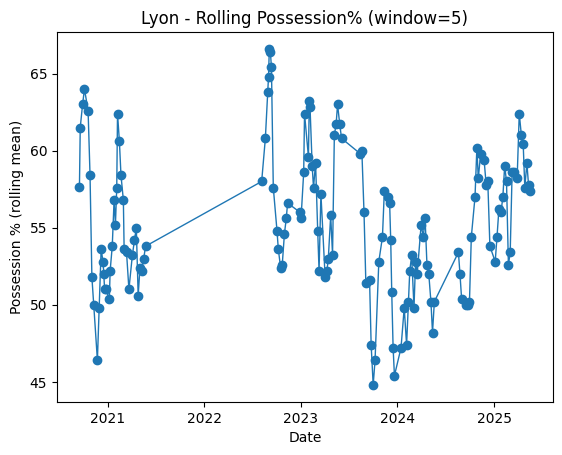

: 

In [ ]:
# CELL 7.1 - rolling averages for top teams
roll_window = 5

if "team" not in team_rows.columns or "date" not in team_rows.columns:
    raise ValueError("team_rows must include 'team' and 'date' columns — rerun earlier cells.")

base_cols = ["team", "date", "xg", "poss"]
available_cols = [c for c in base_cols if c in team_rows.columns]
ts = team_rows[available_cols].dropna(subset=["team", "date"]).copy()
ts["date"] = pd.to_datetime(ts["date"], errors="coerce")
ts = ts.dropna(subset=["date"])  # ensure rolling order is valid

# identify top clubs by match count
match_counts = ts["team"].value_counts()
top_teams = match_counts.head(6).index.tolist()

# compute rolling means per team where data exists
if "xg" in ts.columns:
    ts = ts.sort_values(["team", "date"])
    ts["xg_roll"] = ts.groupby("team")["xg"].transform(
        lambda s: s.rolling(roll_window, min_periods=3).mean()
    )
if "poss" in ts.columns:
    ts = ts.sort_values(["team", "date"])
    ts["poss_roll"] = ts.groupby("team")["poss"].transform(
        lambda s: s.rolling(roll_window, min_periods=3).mean()
    )

for team_name in top_teams:
    sub = ts[ts["team"] == team_name]
    if "xg_roll" in sub.columns and sub["xg_roll"].notna().any():
        fig, ax = plt.subplots()
        ax.plot(sub["date"], sub["xg_roll"], marker="o", linewidth=1)
        ax.set_title(f"{team_name} - Rolling xG (window={roll_window})")
        ax.set_xlabel("Date")
        ax.set_ylabel("xG (rolling mean)")
        plt.show()

    if "poss_roll" in sub.columns and sub["poss_roll"].notna().any():
        fig, ax = plt.subplots()
        ax.plot(sub["date"], sub["poss_roll"], marker="o", linewidth=1)
        ax.set_title(f"{team_name} - Rolling Possession% (window={roll_window})")
        ax.set_xlabel("Date")
        ax.set_ylabel("Possession % (rolling mean)")
        plt.show()

